<a href="https://colab.research.google.com/github/samary12/bayan-project/blob/main/notebooks/02_attention_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# اليوم الأول — الانتباه والمحولات
## Day 1 — Attention & Transformers

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار / Track:** Core → Explore → Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/02_attention_transformers.ipynb)

> السؤال المحوري: كيف يقرر كل Token أي Tokens أخرى يحتاجها لبناء تمثيل سياقي؟
>
> Driving question: How does each token decide which other tokens it needs for a contextual representation?

**النواتج / Outcomes:** تنفيذ Scaled Dot-Product Attention، قراءة الأشكال، تطبيق القناع، فهم Multi-Head Attention وEncoder Block، وتفسير حدود مصفوفة الانتباه.

## 0) خريطة المفاهيم / Concept map

- **Query (Q):** ما الذي أبحث عنه؟
- **Key (K):** ما الصفات التي أعرضها للمطابقة؟
- **Value (V):** ما المعلومة التي سأمررها إذا حصلت على وزن مرتفع؟

\[
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}+M\right)V
\]

سننفذها بـNumPy كي نرى كل خطوة. PyTorch اختياري للمقارنة.

**المتوقع / Expected:** في النهاية تظهر `DAY1_NOTEBOOK2_CORE=PASS`.

In [8]:
import importlib.metadata
import subprocess
import sys
import math
import numpy as np

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2"}
to_install = []
for distribution, expected in PINNED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        to_install.append(f"{distribution}=={expected}")
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *to_install])

SEED = 42
rng = np.random.default_rng(SEED)
print("NumPy:", np.__version__)
print("Pinned:", {name: importlib.metadata.version(name) for name in PINNED})
print("Core runtime ready / بيئة Core جاهزة")

NumPy: 2.1.3
Pinned: {'transformers': '5.15.1', 'tokenizers': '0.22.2'}
Core runtime ready / بيئة Core جاهزة


## 1) تنفيذ Scaled Dot-Product Attention

| Tensor | Shape | المعنى |
|---|---:|---|
| Q | `(T_q, d_k)` | استعلام لكل موضع |
| K | `(T_k, d_k)` | مفتاح لكل موضع |
| V | `(T_k, d_v)` | قيمة لكل موضع |
| Scores | `(T_q, T_k)` | درجة كل استعلام مع كل مفتاح |
| Output | `(T_q, d_v)` | التمثيل السياقي الجديد |

In [9]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    keep_mask: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if q.shape[-1] != k.shape[-1]:
        raise ValueError("Q and K must share d_k")
    if k.shape[-2] != v.shape[-2]:
        raise ValueError("K and V must share sequence length")
    scores = q @ np.swapaxes(k, -1, -2) / math.sqrt(q.shape[-1])
    if keep_mask is not None:
        mask = np.asarray(keep_mask, dtype=bool)
        try:
            mask = np.broadcast_to(mask, scores.shape)
        except ValueError as exc:
            raise ValueError("keep_mask is not broadcastable to scores") from exc
        if np.any(mask.sum(axis=-1) == 0):
            raise ValueError("Every query row must keep at least one key")
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return output, weights, scores

q = np.array([[1.0, 0.0], [0.0, 1.0]])
k = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
v = np.array([[10.0, 0.0], [0.0, 10.0], [5.0, 5.0]])
output, weights, scores = scaled_dot_product_attention(q, k, v)
print("scores shape:", scores.shape)
print("weights:\n", np.round(weights, 3))
print("row sums:", weights.sum(axis=-1))
print("output:\n", np.round(output, 3))
assert output.shape == (2, 2)
assert np.allclose(weights.sum(axis=-1), 1.0)
print("Scaled attention=PASS")

scores shape: (2, 3)
weights:
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]]
row sums: [1. 1.]
output:
 [[6.017 3.983]
 [3.983 6.017]]
Scaled attention=PASS


**المتوقع / Expected:** Scores بحجم `(2, 3)`، ومجموع كل صف من Weights يساوي 1، ثم رسالة نجاح.

### لماذا القسمة على \(\sqrt{d_k}\)؟

عندما يكبر البعد قد تكبر الضربات النقطية، فتدخل Softmax مناطق شديدة الحدة وتضعف التدرجات. التحجيم يحافظ عادة على قيم أكثر استقرارًا.

In [10]:
def entropy(probabilities: np.ndarray) -> float:
    p = np.clip(probabilities, 1e-12, 1.0)
    return float(-np.sum(p * np.log(p), axis=-1).mean())

q_big = rng.normal(size=(6, 64))
k_big = rng.normal(size=(6, 64))
raw_scores = q_big @ k_big.T
unscaled_weights = softmax(raw_scores)
scaled_weights = softmax(raw_scores / math.sqrt(q_big.shape[-1]))
print("mean entropy without scaling:", round(entropy(unscaled_weights), 3))
print("mean entropy with scaling:   ", round(entropy(scaled_weights), 3))
print("Scaling comparison complete")

mean entropy without scaling: 0.379
mean entropy with scaling:    1.624
Scaling comparison complete


## 2) الأقنعة / Masks

في هذه الحزمة نستخدم عقدًا واضحًا: `True` يعني **يسمح بالمشاركة** و`False` يعني **يُحجب**. قد تختلف الدلالة بين المكتبات والواجهات؛ اقرأ توثيق الدالة دائمًا.

القناع السببي يمنع الموضع من رؤية المستقبل. Encoder مثل BERT يستخدم عادة Padding Mask، وليس Causal Mask في الضبط المعتاد.

In [11]:
causal_keep_mask = np.tril(np.ones((2, 3), dtype=bool))
masked_output, masked_weights, _ = scaled_dot_product_attention(q, k, v, keep_mask=causal_keep_mask)
print("keep mask:\n", causal_keep_mask.astype(int))
print("masked weights:\n", np.round(masked_weights, 3))
assert masked_weights[0, 1] == 0.0
assert masked_weights[0, 2] == 0.0
print("Mask semantics=PASS")

keep mask:
 [[1 0 0]
 [1 1 0]]
masked weights:
 [[1.   0.   0.  ]
 [0.33 0.67 0.  ]]
Mask semantics=PASS


## 3) من رأس واحد إلى Multi-Head

تقسم الرؤوس البعد `d_model` إلى أجزاء. كل رأس يتعلم إسقاطات مختلفة لـQ/K/V، ثم تدمج المخرجات. تعدد الرؤوس يتيح علاقات مختلفة، لكنه لا يضمن أن كل رأس يملك تفسيرًا لغويًا بشريًا.

In [12]:
def split_heads(x: np.ndarray, num_heads: int) -> np.ndarray:
    batch, seq_len, d_model = x.shape
    if d_model % num_heads != 0:
        raise ValueError("d_model must be divisible by num_heads")
    d_head = d_model // num_heads
    return x.reshape(batch, seq_len, num_heads, d_head).transpose(0, 2, 1, 3)


def combine_heads(x: np.ndarray) -> np.ndarray:
    batch, num_heads, seq_len, d_head = x.shape
    return x.transpose(0, 2, 1, 3).reshape(batch, seq_len, num_heads * d_head)

x = rng.normal(size=(2, 5, 12))
heads = split_heads(x, num_heads=3)
combined = combine_heads(heads)
print("input:", x.shape)
print("split:", heads.shape, "= (batch, heads, tokens, d_head)")
print("combined:", combined.shape)
assert heads.shape == (2, 3, 5, 4)
assert np.allclose(combined, x)
print("Multi-head shape journey=PASS")

input: (2, 5, 12)
split: (2, 3, 5, 4) = (batch, heads, tokens, d_head)
combined: (2, 5, 12)
Multi-head shape journey=PASS


## 4) Encoder Block وBERT

Encoder block مبسط:

1. Multi-Head Self-Attention.
2. Residual connection + Layer Normalization.
3. Feed-Forward Network لكل موضع.
4. Residual connection + Layer Normalization.

تضاف معلومات الموضع لأن الانتباه وحده لا يعرف ترتيب الكلمات. BERT يبني مكدس Encoder ثنائي السياق؛ اختيار `[CLS]` للتصنيف أو تمثيل كل Token لـNER يعتمد على المهمة.

In [13]:
try:
    import torch
    torch.manual_seed(SEED)
    layer = torch.nn.TransformerEncoderLayer(
        d_model=12, nhead=3, dim_feedforward=24,
        dropout=0.0, batch_first=True, norm_first=False,
    )
    layer.eval()
    torch_x = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        encoder_output = layer(torch_x)
    print("PyTorch encoder output:", tuple(encoder_output.shape))
    assert tuple(encoder_output.shape) == (2, 5, 12)
    print("Optional encoder layer=PASS")
except ModuleNotFoundError:
    print("PyTorch is optional here; NumPy Core remains complete.")

PyTorch encoder output: (2, 5, 12)
Optional encoder layer=PASS


## 5) مقارنة اختيارية مع PyTorch SDPA

إذا كانت PyTorch متاحة، نقارن تنفيذ NumPy مع الدالة الرسمية بأبعاد صغيرة وبدون Dropout.

In [14]:
try:
    import torch
    import torch.nn.functional as F
    tq = torch.tensor(q, dtype=torch.float64)[None, None, :, :]
    tk = torch.tensor(k, dtype=torch.float64)[None, None, :, :]
    tv = torch.tensor(v, dtype=torch.float64)[None, None, :, :]
    torch_result = F.scaled_dot_product_attention(tq, tk, tv, dropout_p=0.0)
    np_result = output[None, None, :, :]
    max_difference = float(np.max(np.abs(torch_result.numpy() - np_result)))
    print("max NumPy/PyTorch difference:", f"{max_difference:.3e}")
    assert max_difference < 1e-9
    print("NumPy/PyTorch parity=PASS")
except ModuleNotFoundError:
    print("PyTorch unavailable; parity check skipped without affecting Core.")

max NumPy/PyTorch difference: 4.441e-16
NumPy/PyTorch parity=PASS


## 6) تدقيق معاملات checkpointين / Two-checkpoint parameter audit

نقرأ إعدادات `mBERT` و`CAMeLBERT-DA` ونحسب معاملات BERT طبقةً بطبقة. هذا يحقق عدًّا قابلًا للمراجعة دون الادعاء بأن الحجم وحده يحدد الجودة. الـcheckpointان مختلفان في القاموس والتغطية؛ وتبقى المقارنة المهمة مرتبطة ببيانات المهمة وشرائحها.

In [15]:
from transformers import AutoConfig

AUDIT_CHECKPOINTS = [
    "google-bert/bert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da",
]
EXPECTED_TOTALS = {
    "google-bert/bert-base-multilingual-cased": 177_853_440,
    "CAMeL-Lab/bert-base-arabic-camelbert-da": 109_081_344,
}

def bert_parameter_audit(model_id: str) -> dict:
    config = AutoConfig.from_pretrained(model_id)
    assert config.model_type == "bert"
    hidden = config.hidden_size
    intermediate = config.intermediate_size
    embeddings = (
        config.vocab_size * hidden
        + config.max_position_embeddings * hidden
        + config.type_vocab_size * hidden
        + 2 * hidden
    )
    per_layer = (
        3 * (hidden * hidden + hidden)
        + (hidden * hidden + hidden) + 2 * hidden
        + (hidden * intermediate + intermediate)
        + (intermediate * hidden + hidden) + 2 * hidden
    )
    pooler = hidden * hidden + hidden
    total = embeddings + config.num_hidden_layers * per_layer + pooler
    return {
        "model_id": model_id, "vocab_size": config.vocab_size,
        "total_parameters": total,
        "embedding_share": embeddings / total,
    }

parameter_audits = [bert_parameter_audit(model_id) for model_id in AUDIT_CHECKPOINTS]
for item in parameter_audits:
    print(
        f'{item["model_id"]} | vocab={item["vocab_size"]:,} | '
        f'total={item["total_parameters"]:,} | '
        f'embeddings={item["embedding_share"]:.1%}'
    )
assert all(item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]] for item in parameter_audits)
print("TWO_CHECKPOINT_PARAMETER_AUDIT=PASS")

google-bert/bert-base-multilingual-cased | vocab=119,547 | total=177,853,440 | embeddings=51.8%
CAMeL-Lab/bert-base-arabic-camelbert-da | vocab=30,000 | total=109,081,344 | embeddings=21.5%
TWO_CHECKPOINT_PARAMETER_AUDIT=PASS


## 7) Forward pass فعلي وخريطة رأس / Actual forward pass and one head

نستخدم checkpoint متعدد اللغات من عائلة BERT نفسها في اليوم الثاني، ونعد معاملاته، ونتتبع shapes، ثم نعرض رأس attention واحدًا للعينة العربية. الخريطة **وصف لما حسبته الطبقة** وليست تفسيرًا سببيًا لقرار نموذج.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Parameters: 134,734,080
Hidden-state shape: (2, 10, 768)
Attention tensor [batch, heads, query, key]: (2, 12, 10, 10)
Arabic tokens: ['[CLS]', 'ال', '##خدمة', 'لم', 'ت', '##ت', '##أ', '##خر', '.', '[SEP]']
Row-sum range: 0.9999998211860657 1.0


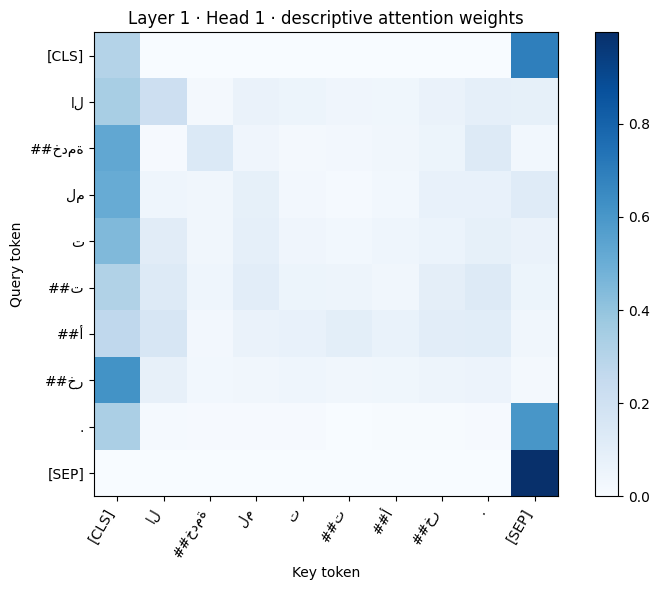

ACTUAL_TRANSFORMER_FORWARD=PASS


In [16]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
ACTUAL_MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
actual_tokenizer = AutoTokenizer.from_pretrained(ACTUAL_MODEL_ID, use_fast=True)
actual_model = AutoModel.from_pretrained(ACTUAL_MODEL_ID, attn_implementation="eager")
actual_model.eval()

sentences = ["الخدمة لم تتأخر.", "The service was not delayed."]
encoded = actual_tokenizer(sentences, padding=True, truncation=True, max_length=32, return_tensors="pt")
with torch.no_grad():
    forward = actual_model(**encoded, output_attentions=True)

parameter_count = sum(parameter.numel() for parameter in actual_model.parameters())
attention_shape = tuple(forward.attentions[0].shape)
hidden_shape = tuple(forward.last_hidden_state.shape)
arabic_tokens = actual_tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
valid_length = int(encoded["attention_mask"][0].sum())
head_weights = forward.attentions[0][0, 0, :valid_length, :valid_length].cpu().numpy()

print(f"Model: {ACTUAL_MODEL_ID}")
print(f"Parameters: {parameter_count:,}")
print("Hidden-state shape:", hidden_shape)
print("Attention tensor [batch, heads, query, key]:", attention_shape)
print("Arabic tokens:", arabic_tokens[:valid_length])
print("Row-sum range:", float(head_weights.sum(-1).min()), float(head_weights.sum(-1).max()))

figure, axis = plt.subplots(figsize=(8, 6))
image = axis.imshow(head_weights, cmap="Blues", vmin=0.0)
axis.set_xticks(range(valid_length), arabic_tokens[:valid_length], rotation=60, ha="right")
axis.set_yticks(range(valid_length), arabic_tokens[:valid_length])
axis.set_xlabel("Key token")
axis.set_ylabel("Query token")
axis.set_title("Layer 1 · Head 1 · descriptive attention weights")
figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

assert parameter_count > 100_000_000
assert hidden_shape[:2] == tuple(encoded["input_ids"].shape)
assert attention_shape[0] == 2 and attention_shape[2] == attention_shape[3]
assert np.allclose(head_weights.sum(-1), 1.0, atol=1e-5)
print("ACTUAL_TRANSFORMER_FORWARD=PASS")

## 8) ما الذي لا تثبته خريطة الانتباه؟

قد تساعد الأوزان على الفحص، لكنها لا تثبت وحدها سبب قرار النموذج ولا تساوي تفسيرًا سببيًا. افصل بين:

- **وصف:** أين وضعت طبقة/رأس أوزانًا أعلى؟
- **ادعاء تفسيري:** لماذا اتخذ النموذج القرار؟ يحتاج اختبارات إضافية كالإزالة أو التبديل أو أساليب تفسير أخرى.

لا تعرض Heatmap واحدة كبرهان نهائي.

## 9) تمارين المستويات / Challenge lanes

- **Core:** غيّر V واشرح كيف يتغير Output مع ثبات الأوزان.
- **Explore:** أنشئ Padding Mask لدفعة من تسلسلين وتحقق أن الحشو يحصل على وزن صفر.
- **Distinction:** قارن زمن التنفيذ لأطوال `T=32,64,128,256` واشرح لماذا ذاكرة Scores تنمو تقريبًا مع \(T^2\). لا تعمم نتيجة جهاز واحد على كل البيئات.

### سؤال قرار / Decision prompt

اكتب في 3–5 أسطر: أي قناع تحتاجه في مشروعك؟ ما شكل Q/K/V المتوقع؟ وما الخطأ الذي سيظهر لو انعكست دلالة القناع؟

In [17]:
core_checks = {
    "weights_sum_to_one": np.allclose(weights.sum(axis=-1), 1.0),
    "two_checkpoint_parameter_audit": len(parameter_audits) == 2 and all(
        item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]]
        for item in parameter_audits
    ),
    "actual_forward": parameter_count > 100_000_000 and len(forward.attentions) > 0,
    "output_shape": output.shape == (2, 2),
    "masked_positions_zero": masked_weights[0, 1] == 0 and masked_weights[0, 2] == 0,
    "heads_round_trip": np.allclose(combined, x),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK2_CORE=PASS")

weights_sum_to_one: PASS
two_checkpoint_parameter_audit: PASS
actual_forward: PASS
output_shape: PASS
masked_positions_zero: PASS
heads_round_trip: PASS
DAY1_NOTEBOOK2_CORE=PASS


## نقطة GitHub / GitHub checkpoint

1. احفظ نسخة في مستودعك العام داخل `notebooks/`.
2. Commit: `feat(day1): implement scaled attention lab`.
3. أضف إلى تقرير اليوم جدول Shapes وشرح القناع، لا مجرد مخرجات منسوخة.
4. اربط Commit في `README.md`.

**دليل الاكتمال:** `DAY1_NOTEBOOK2_CORE=PASS` + إجابة سؤال القرار + رابط Commit عام.

**التالي:** ارجع إلى [صفحة مختبرات اليوم الأول](../day-01/04-labs-checkpoint.md) لإكمال بوابة المشروع Gate A.